In [1]:
from pathlib import Path

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

import mistsim.plotting as msplt

%matplotlib widget

JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


In [13]:
results_dir = Path("results/40mhz")

# 7 nominal runs in order of increasing coverage
runs = [
    "mars",
    "mars-nv",
    "mars-lake",
    "mars-nv-lake",
    "mars-nv-lake-alma",
    "alma-torres",
    "all-nominal",
]
labels = [
    "MARS",
    "MARS+NV",
    "MARS+Lake",
    "MARS+NV+Lake",
    "MARS+NV+Lake+ALMA",
    "ALMA+Torres",
    "All nominal",
]

data = {}
x_true = None
lmax = None

for run, lab in zip(runs, labels):
    d = np.load(results_dir / f"{run}.npz")
    data[run] = d
    if x_true is None:
        x_true = d["x_true"]
        lmax = int(d["lmax"])

print(f"lmax = {lmax}, {len(data)} runs loaded")
for lab, run in zip(labels, runs):
    nvec = int(data[run]["nvec"])
    nsv = len(data[run]["Sigma"])
    print(f"  {lab}: {run} (nvec={nvec}, k={nsv})")

lmax = 90, 7 runs loaded
  MARS: mars (nvec=258, k=800)
  MARS+NV: mars-nv (nvec=614, k=1200)
  MARS+Lake: mars-lake (nvec=437, k=1200)
  MARS+NV+Lake: mars-nv-lake (nvec=789, k=1200)
  MARS+NV+Lake+ALMA: mars-nv-lake-alma (nvec=1133, k=1200)
  ALMA+Torres: alma-torres (nvec=702, k=1200)
  All nominal: all-nominal (nvec=1465, k=2000)


In [14]:
# Check for SVD truncation: if the last singular value is still
# large, k was too small and we're missing modes.
print("=== SVD Truncation Check ===")
truncated = []
for run, lab in zip(runs, labels):
    Sigma = data[run]["Sigma"]
    nvec = int(data[run]["nvec"])
    k = len(Sigma)
    last_sv = Sigma[-1] if k > 0 else 0
    ratio = last_sv / Sigma[0] if Sigma[0] > 0 else 0
    flag = ""
    if nvec == k:
        flag = " ** TRUNCATED: nvec == k, likely missing modes **"
        truncated.append(lab)
    elif last_sv > 1e-6:
        flag = f" (last SV = {last_sv:.2e}, may benefit from higher k)"
    print(f"  {lab}: k={k}, nvec={nvec}, "
          f"Sigma[-1]={last_sv:.2e}{flag}")

if truncated:
    print(f"\nWARNING: {truncated} hit the SVD budget ceiling. "
          "Rerun with higher n_singular_values.")

=== SVD Truncation Check ===
  MARS: k=800, nvec=258, Sigma[-1]=4.72e-11
  MARS+NV: k=1200, nvec=614, Sigma[-1]=6.76e-11
  MARS+Lake: k=1200, nvec=437, Sigma[-1]=5.83e-11
  MARS+NV+Lake: k=1200, nvec=789, Sigma[-1]=7.58e-11
  MARS+NV+Lake+ALMA: k=1200, nvec=1133, Sigma[-1]=8.80e-11
  ALMA+Torres: k=1200, nvec=702, Sigma[-1]=5.44e-11
  All nominal: k=2000, nvec=1465, Sigma[-1]=9.59e-11


# Nominal Runs Comparison (40 MHz)

Comparing 7 beam/site combinations for mapmaking performance at 40 MHz.

## Singular Value Spectra

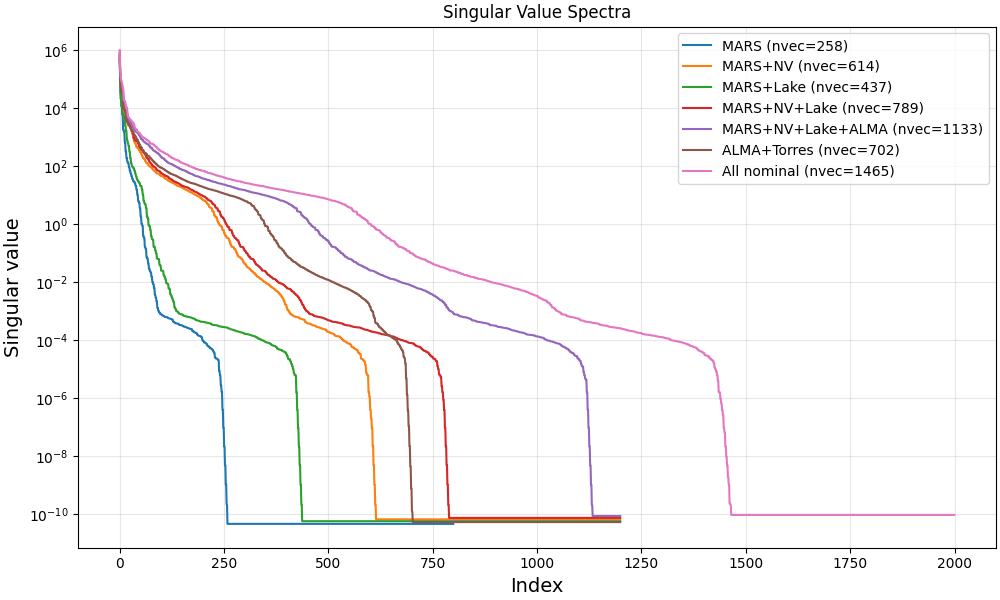

In [15]:
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
for run, lab in zip(runs, labels):
    Sigma = data[run]["Sigma"]
    nvec = int(data[run]["nvec"])
    ax.semilogy(Sigma, lw=1.5, label=f"{lab} (nvec={nvec})")
ax.set_xlabel("Index", fontsize=14)
ax.set_ylabel("Singular value", fontsize=14)
ax.set_title("Singular Value Spectra")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.show()

## Wiener Filter Factors

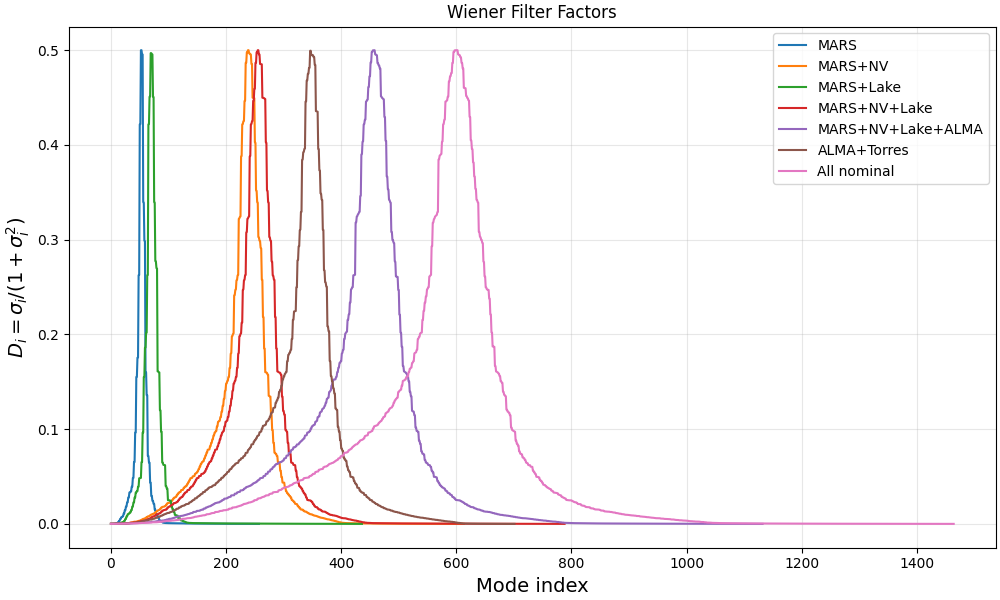

In [16]:
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
for run, lab in zip(runs, labels):
    Sigma = data[run]["Sigma"]
    nvec = int(data[run]["nvec"])
    Dnum = Sigma[:nvec]
    D = Dnum / (1 + Dnum**2)
    ax.plot(D, lw=1.5, label=lab)
ax.set_xlabel("Mode index", fontsize=14)
ax.set_ylabel(r"$D_i = \sigma_i / (1 + \sigma_i^2)$", fontsize=14)
ax.set_title("Wiener Filter Factors")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.show()

## Information Metrics

| Metric | Formula | Meaning |
|--------|---------|---------|
| Shannon info | $\frac{1}{2}\sum \log(1 + \sigma_i^2)$ | Total mutual information (nats) |
| Effective DoF | $\sum \sigma_i^2 / (1 + \sigma_i^2)$ | Number of well-constrained modes |
| Effective rank | $\#\{i : \sigma_i > 1\}$ | Modes with SNR > 1 |

In [17]:
rows = []
for run, lab in zip(runs, labels):
    Sigma = data[run]["Sigma"]
    nvec = int(data[run]["nvec"])
    s2 = Sigma[:nvec] ** 2
    shannon = 0.5 * np.sum(np.log(1 + s2))
    eff_dof = np.sum(s2 / (1 + s2))
    eff_rank = int(np.sum(Sigma[:nvec] > 1))
    rows.append((lab, nvec, f"{shannon:.1f}", f"{eff_dof:.1f}", eff_rank))

header = f"{'Run':<22s} {'nvec':>6s} {'Shannon':>10s} {'Eff DoF':>10s} {'Eff rank':>10s}"
print(header)
print("-" * len(header))
for lab, nv, sh, dof, rk in rows:
    print(f"{lab:<22s} {nv:>6d} {sh:>10s} {dof:>10s} {rk:>10d}")

Run                      nvec    Shannon    Eff DoF   Eff rank
--------------------------------------------------------------
MARS                      258      253.6       53.7         54
MARS+NV                   614      964.4      239.4        238
MARS+Lake                 437      343.4       70.7         69
MARS+NV+Lake              789     1047.1      256.2        255
MARS+NV+Lake+ALMA        1133     1780.0      457.0        457
ALMA+Torres               702     1337.3      347.4        348
All nominal              1465     2292.3      599.9        599


## Transfer Functions

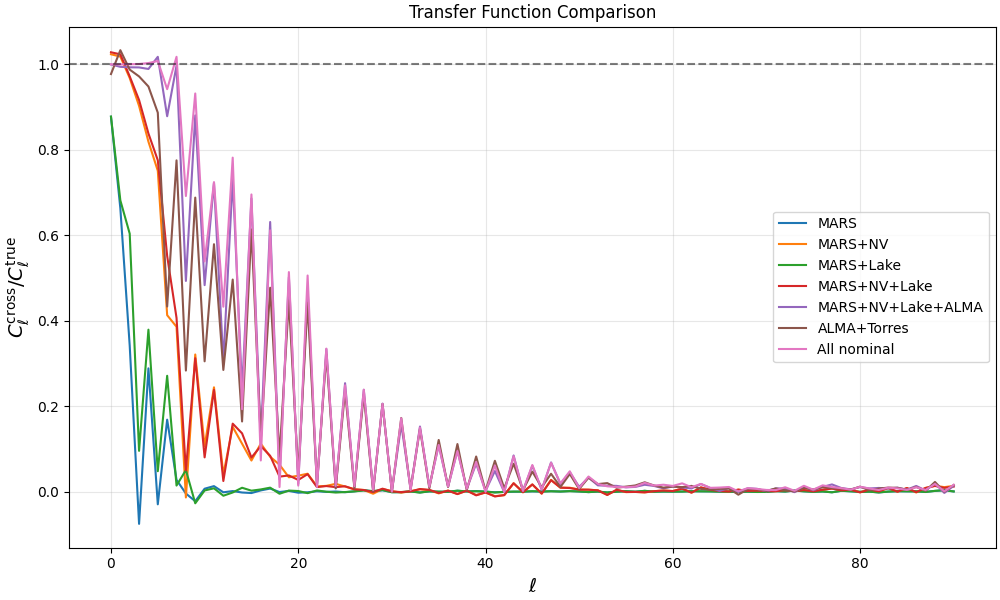

In [18]:
cl_true = hp.alm2cl(x_true)
valid = cl_true > 0

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
for run, lab in zip(runs, labels):
    x_rec = data[run]["x_rec"]
    cl_cross = hp.alm2cl(x_true, x_rec)
    tf = np.zeros_like(cl_true)
    tf[valid] = cl_cross[valid] / cl_true[valid]
    ax.plot(np.arange(len(tf)), tf, lw=1.5, label=lab)
ax.axhline(1, color="k", ls="--", alpha=0.5)
ax.set_xlabel(r"$\ell$", fontsize=14)
ax.set_ylabel(r"$C_\ell^{\rm cross} / C_\ell^{\rm true}$", fontsize=14)
ax.set_title("Transfer Function Comparison")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.show()

## Power Spectra

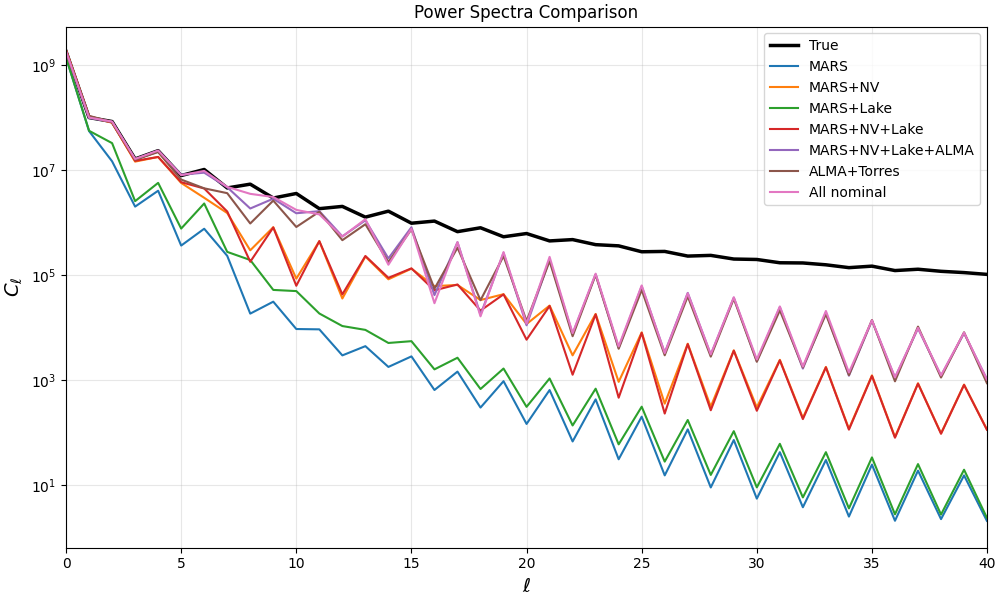

In [21]:
ell = np.arange(len(cl_true))

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
ax.plot(ell, cl_true, "k-", lw=2.5, label="True")
for run, lab in zip(runs, labels):
    x_rec = data[run]["x_rec"]
    ax.plot(ell, hp.alm2cl(x_rec), lw=1.5, label=lab)
ax.set_yscale("log")
ax.set_xlabel(r"$\ell$", fontsize=14)
ax.set_ylabel(r"$C_\ell$", fontsize=14)
ax.set_title("Power Spectra Comparison")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0, 40)
plt.show()

## Cumulative Residual RMS vs ell

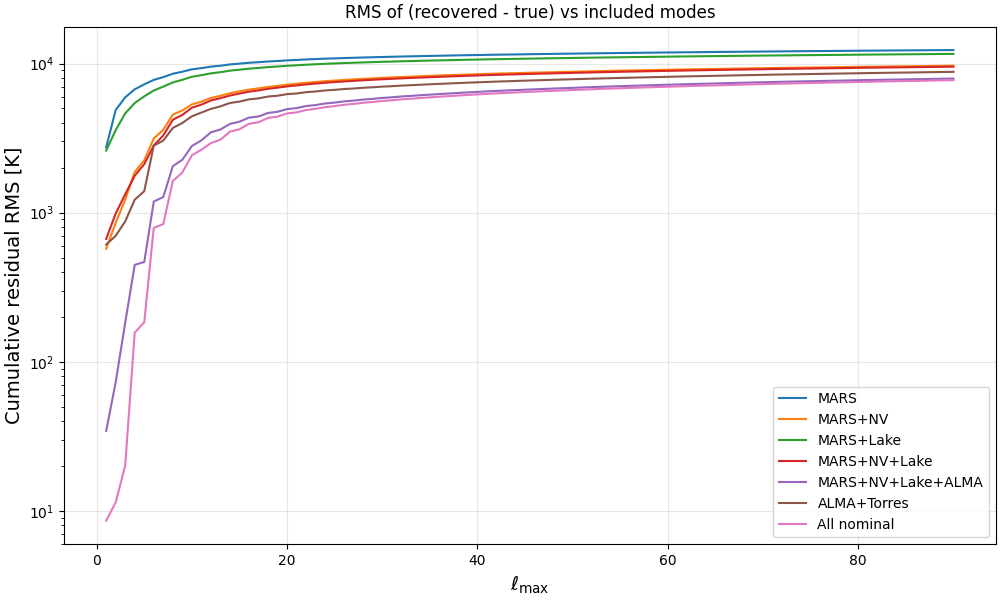

In [22]:
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
for run, lab in zip(runs, labels):
    x_rec = data[run]["x_rec"]
    cl_res = hp.alm2cl(x_rec - x_true)
    ell_arr = np.arange(len(cl_res))
    weights = (2 * ell_arr + 1) / (4 * np.pi)
    rms_cum = np.sqrt(np.cumsum(weights * cl_res))
    ax.semilogy(ell_arr[1:], rms_cum[1:], lw=1.5, label=lab)
ax.set_xlabel(r"$\ell_{\rm max}$", fontsize=14)
ax.set_ylabel("Cumulative residual RMS [K]", fontsize=14)
ax.set_title("RMS of (recovered - true) vs included modes")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.show()

## Fractional Residual Power vs ell

$C_\ell^{\rm res} / C_\ell^{\rm true}$ — fraction of signal power lost at each multipole.
0 = perfect recovery, 1 = no constraining power.

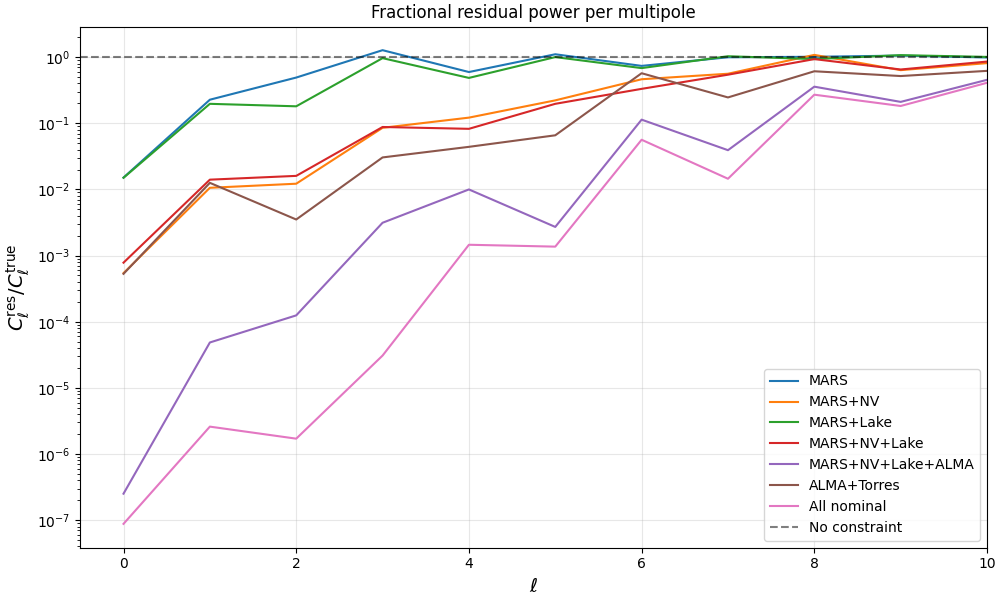

In [23]:
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
cl_true = hp.alm2cl(x_true)
for run, lab in zip(runs, labels):
    x_rec = data[run]["x_rec"]
    cl_res = hp.alm2cl(x_rec - x_true)
    #frac = np.zeros_like(cl_true)
    #valid = cl_true > 0
    #frac[valid] = cl_res[valid] / cl_true[valid]
    frac = cl_res / cl_true
    ell_arr = np.arange(len(frac))
    #ax.semilogy(ell_arr[1:], frac[1:], lw=1.5, label=lab)
    ax.semilogy(ell_arr, frac, lw=1.5, label=lab)
ax.axhline(1, color="k", ls="--", alpha=0.5, label="No constraint")
ax.set_xlabel(r"$\ell$", fontsize=14)
ax.set_ylabel(r"$C_\ell^{\rm res} / C_\ell^{\rm true}$", fontsize=14)
ax.set_title("Fractional residual power per multipole")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(-0.5, 10)
plt.show()

## Map Comparison Grid

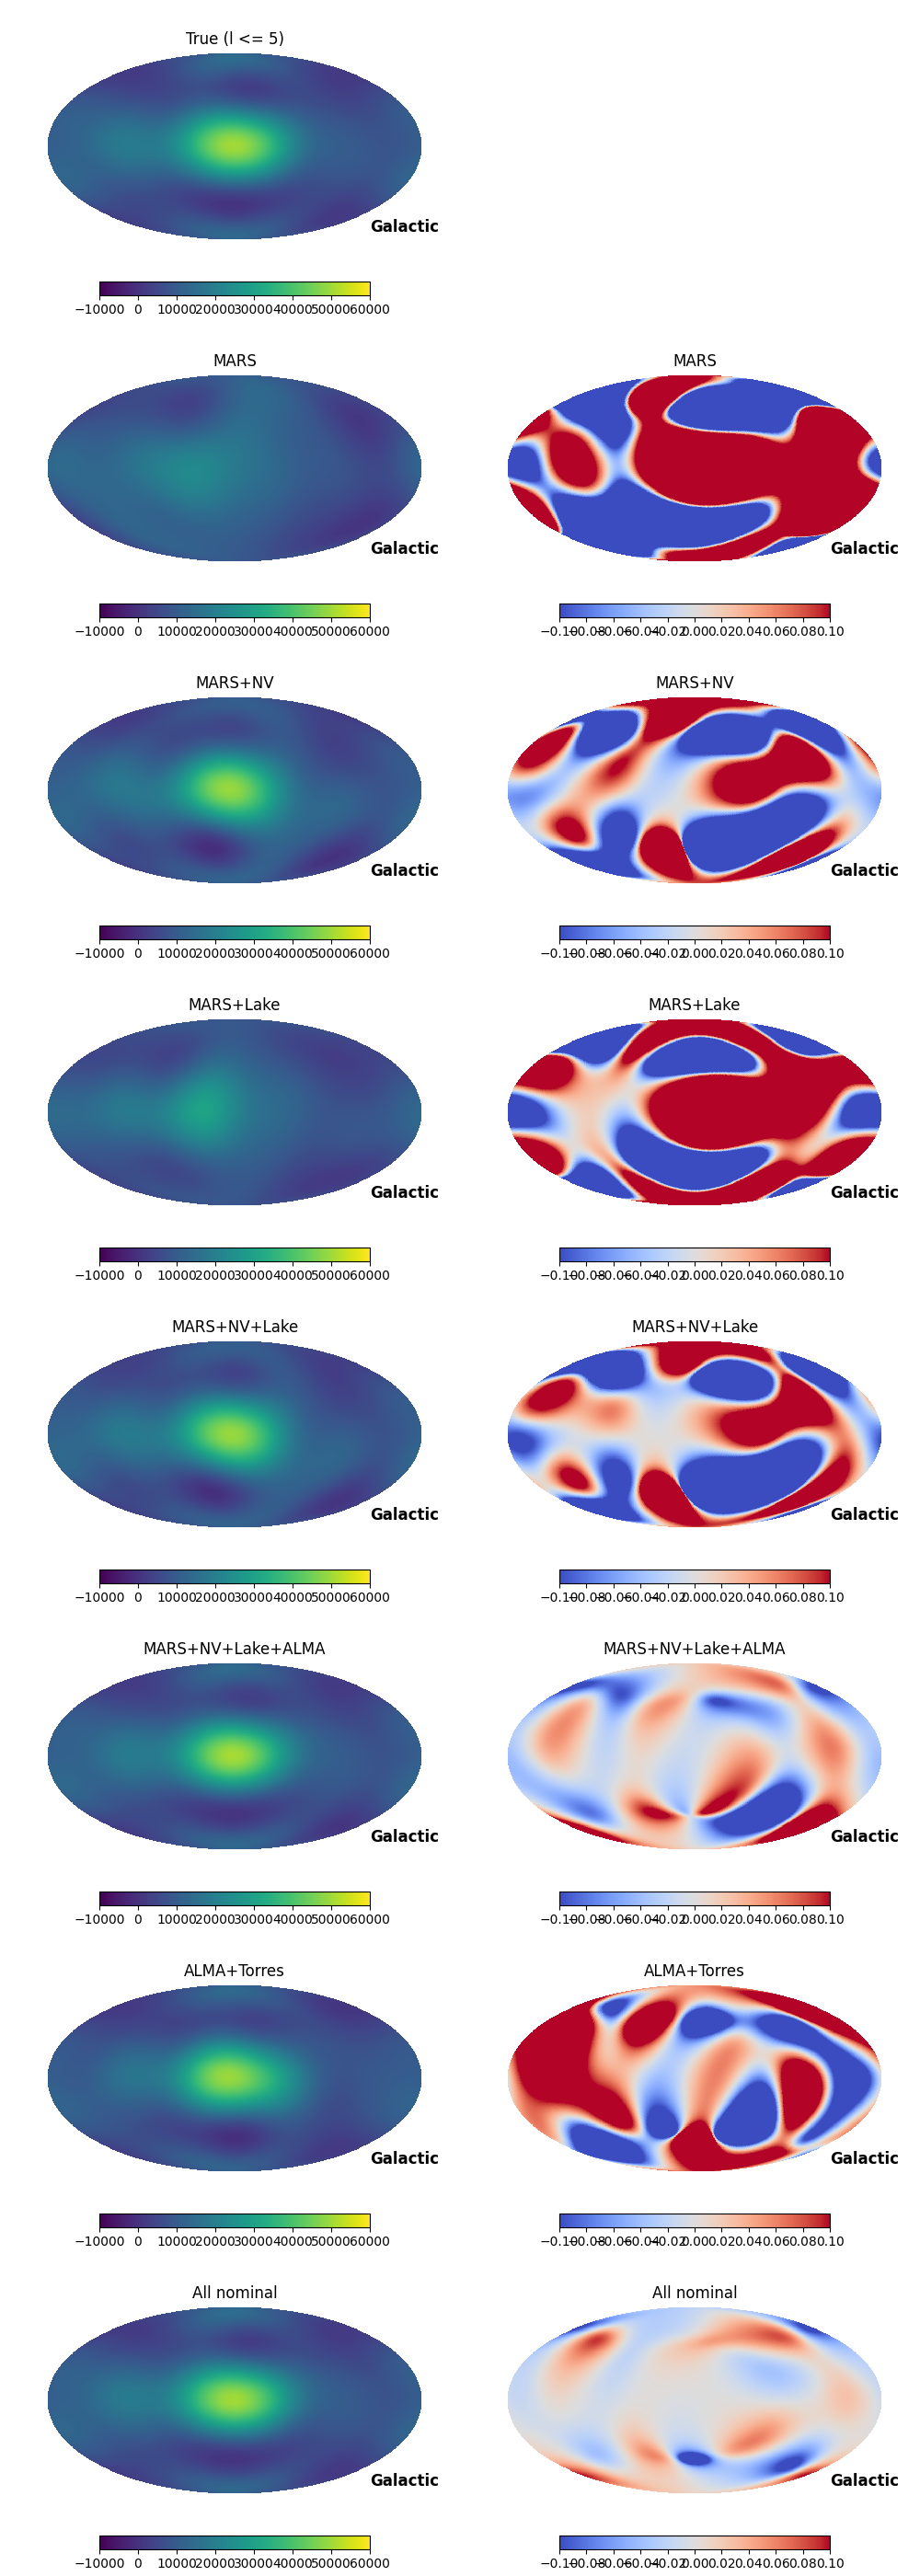

In [28]:
x_recs = [data[run]["x_rec"] for run in runs]

fig = msplt.plot_comparison_grid(
    x_true, x_recs, labels, lmax, plot_lmax=5,
    nside=128, plot_galactic=True, frac_range=.1,
    ratio=True, orientation="vertical",
)
plt.show()